In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve

from lmfit.models import GaussianModel, LorentzianModel, PseudoVoigtModel

import plotly.graph_objects as go



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

In [3]:
file_path = r"../Data/Raman/Ni2Si_900_Green_50%_100x_60sx10_01.txt"

data = pd.read_csv(file_path, skiprows=45, encoding='utf-8', delimiter='\t', header=None, names=['Raman shift', 'Intensity'])
print(data.info())

filename = os.path.basename(file_path)
name = filename.split("_", 1)[1].split("grad")[0]
print(name)

<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Raman shift  934 non-null    float64
 1   Intensity    934 non-null    float64
dtypes: float64(2)
memory usage: 14.7 KB
None
900_Green_50%_100x_60sx10_01.txt


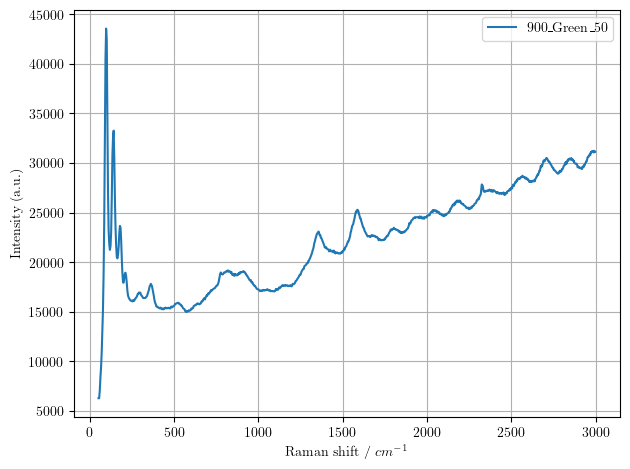

In [4]:
fig, ax = plt.subplots()

ax.plot(data['Raman shift'], data['Intensity'], label=f'{name} XRD Pattern')

# ax.axes.get_yaxis().set_ticklabels([])
plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()

In [5]:
def baseline_als(y, lam=1e5, p=0.001, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2), dtype=None)
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w,0,L,L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

C:\Users\lhager\AppData\Local\Temp\ipykernel_3896\729212169.py:8: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


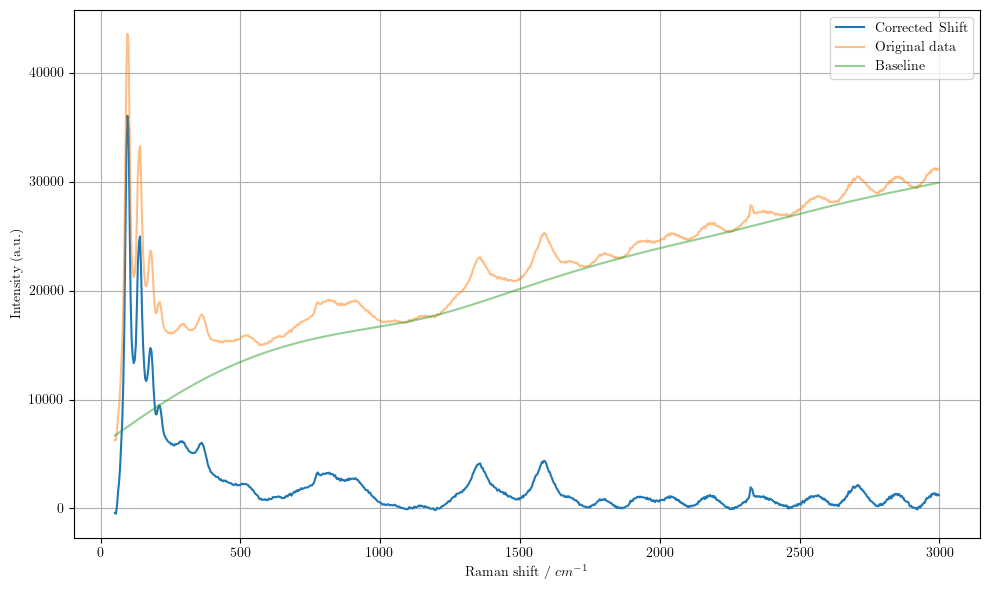

In [6]:
data['Baseline'] = baseline_als(data['Intensity'])
data['Corrected Intensity'] = data['Intensity'] - data['Baseline']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(data['Raman shift'], data['Corrected Intensity'], label=f'Corrected Shift')
ax.plot(data['Raman shift'], data['Intensity'], label=f'Original data', alpha=0.5)
ax.plot(data['Raman shift'], data['Baseline'], label=f'Baseline', alpha=0.5)

# ax.axes.get_yaxis().set_ticklabels([])
plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()

In [ ]:
# data.to_csv(r"../Data/Raman/900_front.csv", sep=';')

### Ich fitte mir die Welt wie sie mir gefällt

In [24]:
mask = (data['Raman shift'] >= 1100) & (data['Raman shift'] <= 1800)
x_fit = data['Raman shift'][mask]
y_fit = data['Corrected Intensity'][mask]

# create model using pseudo-Voigt profiles
def create_carbon_model():
    m1 = PseudoVoigtModel(prefix='g_')
    m2 = PseudoVoigtModel(prefix='d1_')
    m3 = PseudoVoigtModel(prefix='d2_')
    # m4 = PseudoVoigtModel(prefix='d3_')
    # m5 = PseudoVoigtModel(prefix='d4_')
    return m1 + m2 + m3 # + m4 # + m5

model = create_carbon_model()
params = model.make_params()

# Initial Guesses
params['g_center'].set(value=1580, min=1560, max=1600)
params['d1_center'].set(value=1350, min=1330, max=1370)
params['d2_center'].set(value=1620, min=1610, max=1640)

# params['d3_center'].set(value=1400, min=1380, max=1500)
# params['d4_center'].set(value=1200, min=1150, max=1250)

# Set all amplitudes to be positive
for p in params:
    if 'amplitude' in p:
        params[p].set(min=0)

# Fit
result = model.fit(y_fit, params, x=x_fit)
print(result.fit_report())

[[Model]]
    ((Model(pvoigt, prefix='g_') + Model(pvoigt, prefix='d1_')) + Model(pvoigt, prefix='d2_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 26000
    # data points      = 218
    # variables        = 12
    chi-square         = 8831671.18
    reduced chi-square = 42872.1902
    Akaike info crit   = 2336.84043
    Bayesian info crit = 2377.45437
    R-squared          = 0.97279803
##  Warning: uncertainties could not be estimated:
    d1_fraction:   at boundary
    d2_center:     at boundary
[[Variables]]
    g_amplitude:   522014.851 (init = 1)
    g_center:      1585.95491 (init = 1580)
    g_sigma:       40.7105774 (init = 1)
    g_fraction:    0.99968363 (init = 0.5)
    d1_amplitude:  557504.054 (init = 1)
    d1_center:     1354.94648 (init = 1350)
    d1_sigma:      46.0501621 (init = 1)
    d1_fraction:   0.99999984 (init = 0.5)
    d2_amplitude:  0.21277453 (init = 1)
    d2_center:     1610.00000 (init = 1620)
    d2_sigma:      0.9515

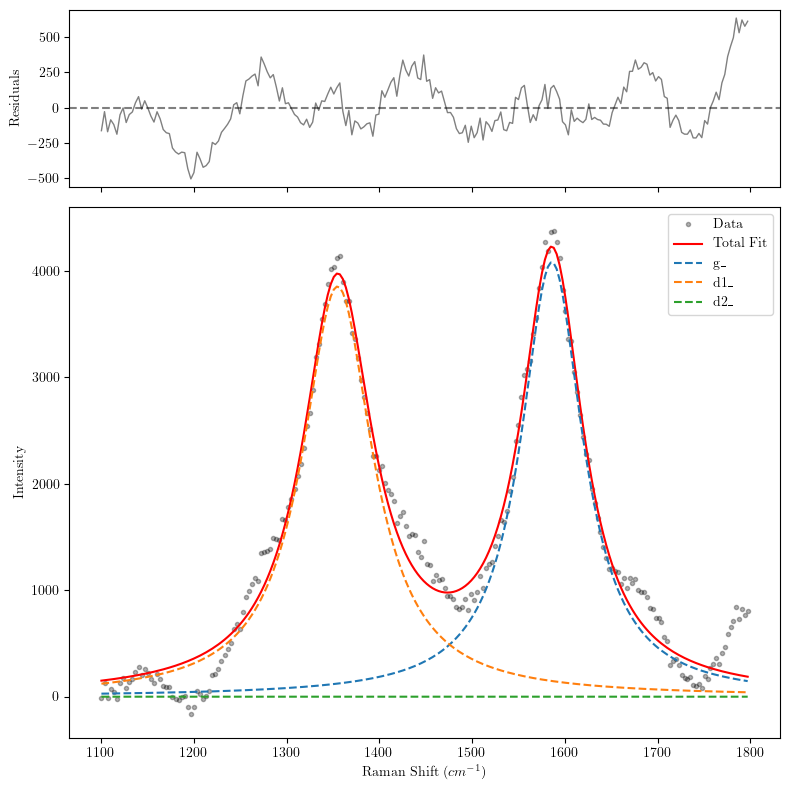

In [26]:
# Create a figure with two subplots (Ratio 1:3)
fig, (ax_res, ax_fit) = plt.subplots(2, 1, sharex=True, 
                                    gridspec_kw={'height_ratios': [1, 3]},
                                    figsize=(8, 8))

# 1. Plot Residuals (Top Panel)
# result.residual is (data - fit)
ax_res.plot(x_fit, result.residual, color='gray', lw=1)
ax_res.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax_res.set_ylabel("Residuals")

# 2. Plot Data and Fit (Bottom Panel)
ax_fit.plot(x_fit, y_fit, 'k.', alpha=0.3, label='Data')
ax_fit.plot(x_fit, result.best_fit, 'r-', label='Total Fit')

# Plot individual components
comps = result.eval_components()
for name, component in comps.items():
    ax_fit.plot(x_fit, component, '--', label=name)

ax_fit.set_xlabel("Raman Shift ($cm^{-1}$)")
ax_fit.set_ylabel("Intensity")
ax_fit.legend()



# peak_names = ['g', 'd1', 'd2', 'd3']
# label_map = {'g': 'G', 'd1': 'D', 'd2': "D'", 'd3': 'D3'}

# for p in peak_names:
#     # Get center and height from the fit results
#     center = result.params[f'{p}_center'].value
#     # Use the model to find the max height of just this component
#     height = result.params[f'{p}_height'].value
    
#     # Add text label with a small vertical offset (e.g., +0.05)
#     plt.text(center, height + 0.05, label_map[p], 
#              ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

- D band (~1350): Structural defects.
- G band (~1580): In-plane vibration of $sp^2$ atoms.
- D' band (~1620): Often appears as a shoulder on the G band in defective graphene.
- A or D'' band (~1500): Amorphous carbon/interstitial defects. This is that "hump" between the D and G peaks.

| Peak Name | Approx. Position (cm−1) | Physical Origin |
|-------|-------|-------|
| G | ~1580 | Ideal $sp^2$ Graphite lattice |
| D1 (D) | ~1350 | Disordered $sp^2$ (Edges/Defects) |
| D2 (D') | ~1620 | Disordered $sp^2$ (Shoulder on G) |
| D3 (A) | ~1500 | Amorphous carbon ($sp^3$ content) |
| D4 | ~1200 | Disordered $sp^2-sp^3$ polyenes |

## Nickel Silicides

In [105]:
# scale_factor = data['Corrected Intensity'].max()
# data['Norm_Intensity'] = data['Corrected Intensity'] / scale_factor

In [110]:
# peaks_idx, _ = signal.find_peaks(data['Norm_Intensity'], distance=10, height=0.05)
peaks_idx, _ = signal.find_peaks(data['Corrected Intensity'], distance=10, height=2000)

peaks = data.loc[peaks_idx, 'Raman shift']
print(peaks)

12       96.3546
24      141.1150
34      178.2480
55      255.7460
65      292.4200
84      361.6970
100     419.6300
113     466.4310
124     505.8410
201     776.9880
213     818.5100
225     859.8420
240     911.2360
374    1357.4200
386    1396.2800
446    1587.9500
826    2708.7200
Name: Raman shift, dtype: float64


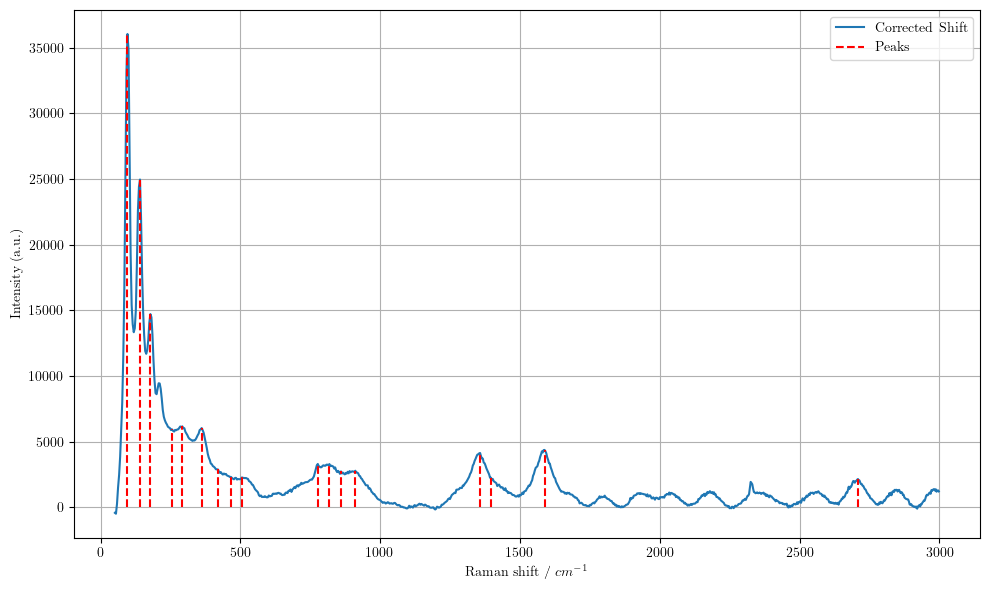

In [111]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(data['Raman shift'], data['Corrected Intensity'], label=f'Corrected Shift')
plt.vlines(peaks.values, ymin=0, ymax=data['Corrected Intensity'].iloc[peaks_idx], color='red', linestyle='--', label='Peaks')

plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()

96.3546 $Ni_2Si$
141.115 $Ni_2Si$
178.248 $Ni_2Si$


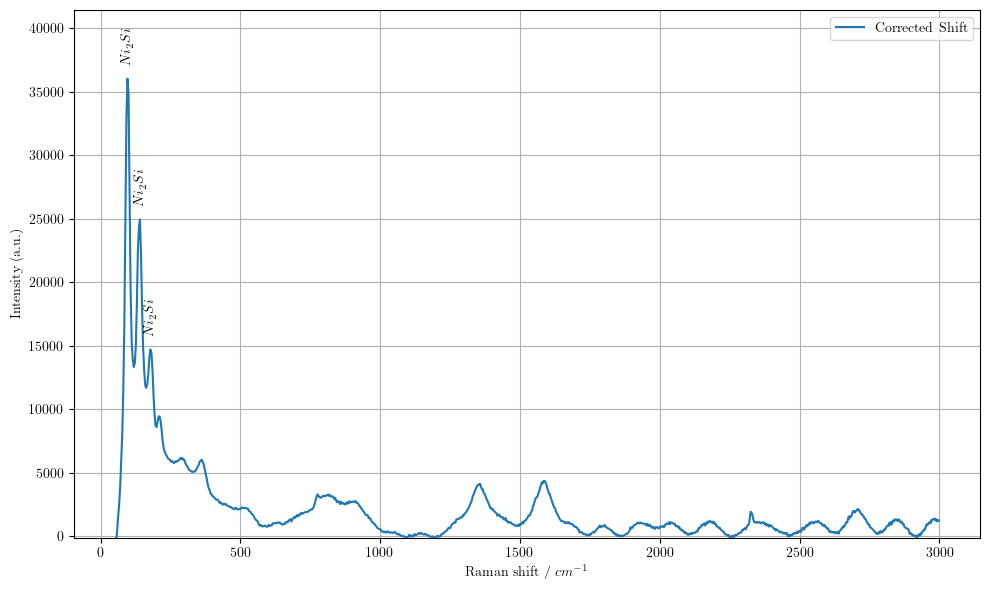

In [137]:
peak_labels = {96.3546: '$Ni_2Si$', 141.1150: '$Ni_2Si$', 178.2480: '$Ni_2Si$'}

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(data['Raman shift'], data['Corrected Intensity'], label=f'Corrected Shift')

for position, name in peak_labels.items():
    print(position, name)
    plt.text(position, data.loc[data['Raman shift'] == position, 'Corrected Intensity'].values[0] + 1000, name, 
            ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
    
plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.ylim([-100, 1.15 * data['Corrected Intensity'].max()])
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()